In [3]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import accuracy_score
from sklearn import tree
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/Users/connorhall/datasets/inst414/module 6 assignment/Maternal Health Risk Data Set.csv')
df

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk


In [5]:
df.dtypes

Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel          str
dtype: object

In [ ]:
print(df.min(),'\n')
print(df.max(),'\n')

# find HeartRate outliers
print(df[df['HeartRate'] < 60])
# remove outliers
df = df[df['HeartRate'] > 60]

Age                   10
SystolicBP            70
DiastolicBP           49
BS                   6.0
BodyTemp            98.0
HeartRate              7
RiskLevel      high risk
dtype: object 

Age                  70
SystolicBP          160
DiastolicBP         100
BS                 19.0
BodyTemp          103.0
HeartRate            90
RiskLevel      mid risk
dtype: object 



,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
499,16,120,75,7.9,98.0,7,low risk
908,16,120,75,7.9,98.0,7,low risk


### split data

In [221]:
X = df.drop(columns=['RiskLevel'])
y = df['RiskLevel']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

### accuracy by max_depth

In [222]:
train_acc_list = []
test_acc_list = []
depths = []

for depth in range(3,12):
    clf = DecisionTreeClassifier(max_depth=depth)
    clf = clf.fit(X_train, y_train)
    y_pred_train = clf.predict(X_train)
    y_pred_test = clf.predict(X_test)
    
    depths.append(depth)
    train_acc_list.append(round(accuracy_score(y_train, y_pred_train), 5))
    test_acc_list.append(round(accuracy_score(y_test, y_pred_test), 5))

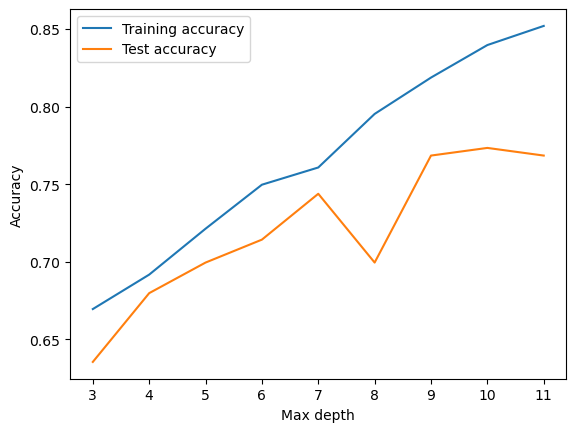

In [223]:
plt.plot(depths, train_acc_list, label='Training accuracy')
plt.plot(depths, test_acc_list, label='Test accuracy')
plt.xlabel('Max depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### incorrect predictions

In [224]:
compare_index = X_test[y_pred_test!=y_test].index
correct_labels = pd.DataFrame(y_test[compare_index])
incorrect_labels = pd.DataFrame(y_pred_test[y_pred_test!=y_test])\
    .set_index(compare_index).rename(columns={0: 'Predicted risk level'})
    
incorrect_pred = X_test[y_pred_test!=y_test].join(correct_labels)
incorrect_pred = incorrect_pred.join(incorrect_labels)
incorrect_pred

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,Predicted risk level
53,19,120,85,7.0,98.0,60,low risk,mid risk
50,25,120,80,7.0,98.0,66,low risk,mid risk
575,19,120,80,7.0,98.0,70,low risk,mid risk
86,21,120,80,6.9,98.0,76,mid risk,low risk
818,60,120,85,15.0,98.0,60,mid risk,high risk
906,19,120,80,7.0,98.0,70,low risk,mid risk
797,43,130,80,18.0,98.0,70,mid risk,high risk
831,21,120,80,7.5,98.0,77,mid risk,low risk
80,16,90,65,6.9,98.0,76,mid risk,low risk
770,23,100,85,6.9,98.0,66,mid risk,low risk


### visualize decision tree

In [225]:
# find correct class order
clf.classes_

array(['high risk', 'low risk', 'mid risk'], dtype=object)

[Text(0.5691964285714286, 0.9375, 'BS <= 7.95\ngini = 0.657\nsamples = 811\nvalue = [216, 328, 267]\nclass = low risk'),
 Text(0.3482142857142857, 0.8125, 'SystolicBP <= 132.5\ngini = 0.567\nsamples = 602\nvalue = [55.0, 320.0, 227.0]\nclass = low risk'),
 Text(0.45870535714285715, 0.875, 'True  '),
 Text(0.25, 0.6875, 'BS <= 7.055\ngini = 0.528\nsamples = 568\nvalue = [26, 320, 222]\nclass = low risk'),
 Text(0.10714285714285714, 0.5625, 'BodyTemp <= 99.5\ngini = 0.541\nsamples = 316\nvalue = [15.0, 138.0, 163.0]\nclass = mid risk'),
 Text(0.05357142857142857, 0.4375, 'SystolicBP <= 125.0\ngini = 0.523\nsamples = 255\nvalue = [6, 127, 122]\nclass = low risk'),
 Text(0.03571428571428571, 0.3125, 'DiastolicBP <= 49.5\ngini = 0.521\nsamples = 240\nvalue = [6, 127, 107]\nclass = low risk'),
 Text(0.017857142857142856, 0.1875, 'gini = 0.0\nsamples = 8\nvalue = [0, 8, 0]\nclass = low risk'),
 Text(0.05357142857142857, 0.1875, 'HeartRate <= 87.0\ngini = 0.524\nsamples = 232\nvalue = [6.0, 11

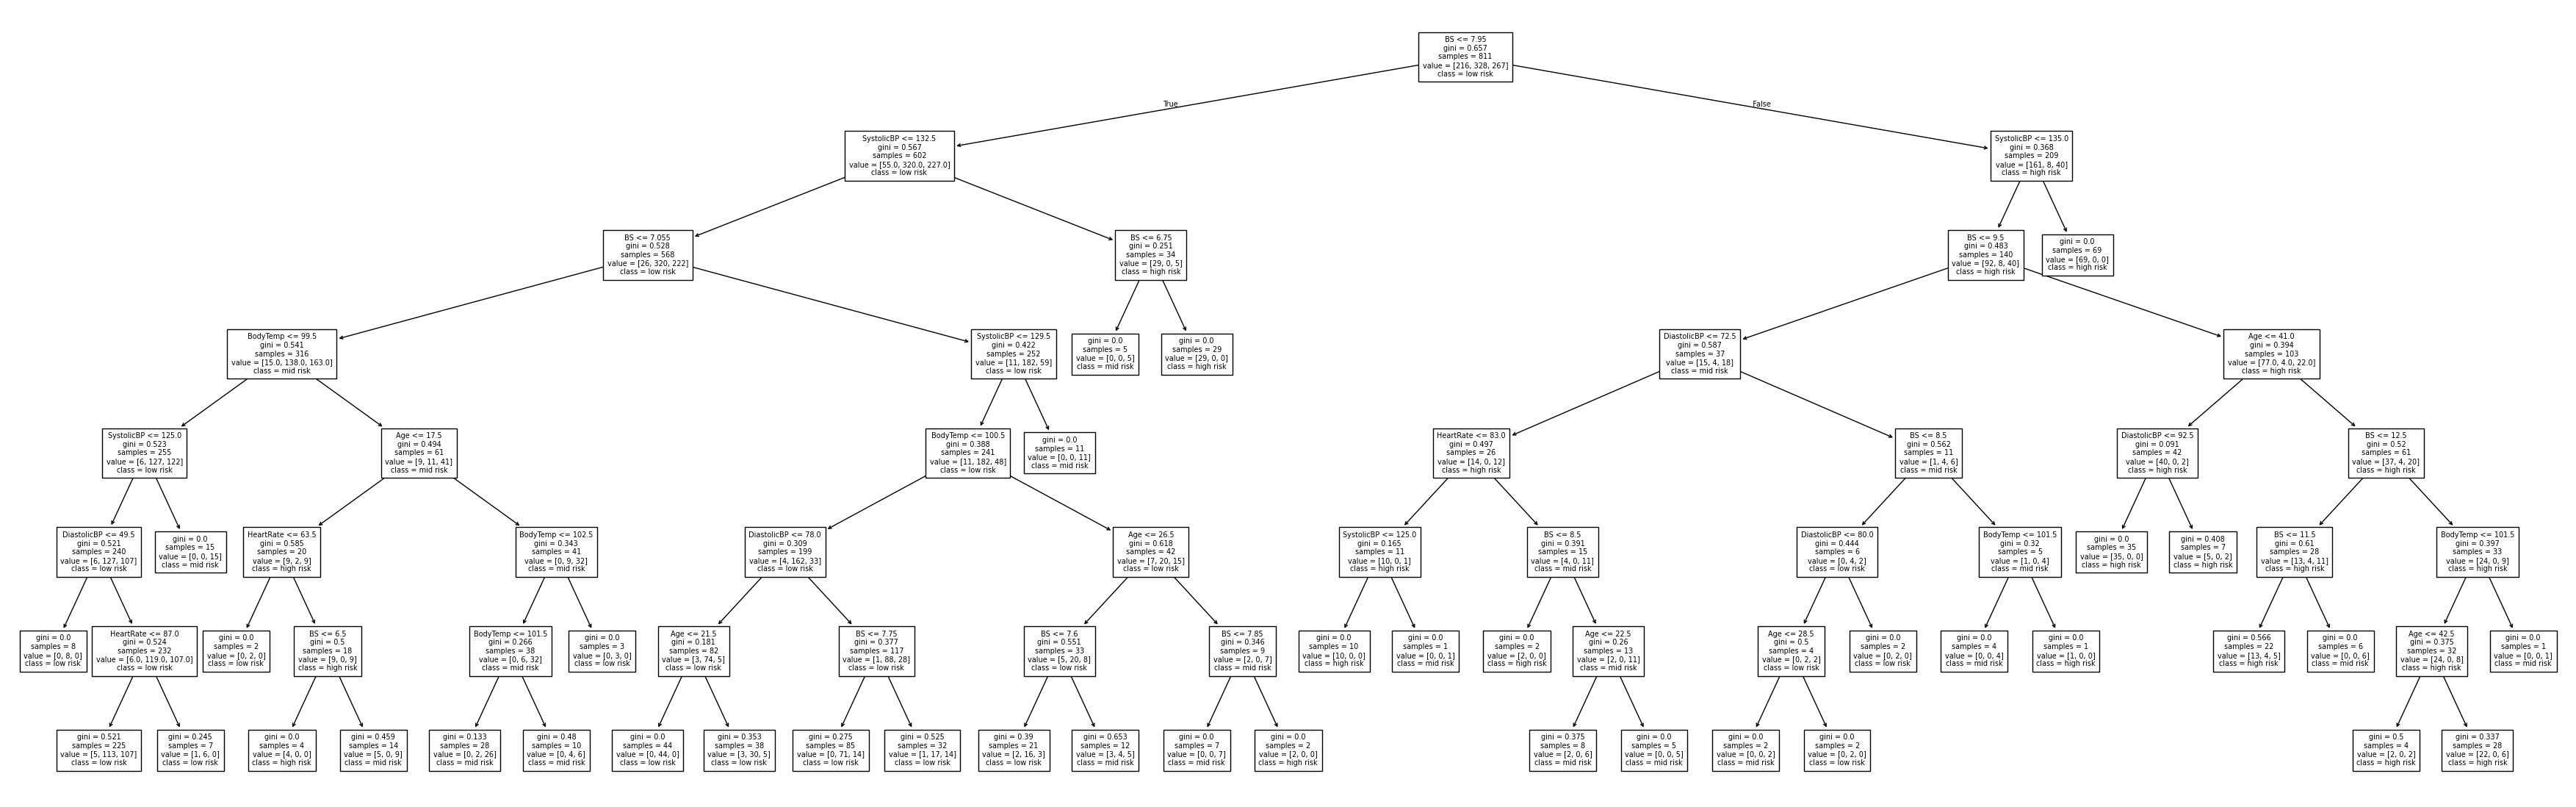

In [226]:
clf = DecisionTreeClassifier(max_depth=7)
clf = clf.fit(X_train, y_train)

plt.figure(figsize=(45,14))
features = df.drop(columns=['RiskLevel']).columns.tolist()
classes = ['high risk', 'low risk', 'mid risk']
tree.plot_tree(clf, feature_names=features, class_names=classes, fontsize=7)